# Proyecto Parte 1: clasificación de sentimiento en reseñas

Curso Aprendizaje de Máquina 2026-20, Universidad de los Andes

**Grupo 29**

1. Nicolás Rey López
2. Andrés Felipe Pinzón Adame
3. Kevin Oviedo García

## Objetivo

Queremos predecir si una reseña de un producto, escrita en español, es negativa, neutral o positiva. La competencia mide el resultado con accuracy, que es el porcentaje de reseñas bien clasificadas.

En esta primera parte solo podemos usar modelos clásicos de scikit-learn y representaciones de texto como bolsa de palabras, TF-IDF y n-gramas. No se permiten redes neuronales ni embeddings preentrenados.

Contenido del notebook:

1. Configuración del entorno
2. Carga de los datos
3. Exploración y calidad de los datos
4. Preprocesamiento del texto
5. Partición de los datos
6. Elección de la representación
7. Comparación de modelos
8. Evaluación en la prueba interna
9. Qué aprendió el modelo
10. Análisis de errores
11. Fase 2: el orden de las opiniones
12. Modelo final y archivo de envío
13. Registro de envíos
14. Conclusiones

## 1. Configuración del entorno

In [1]:
import os
import re
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_val_score)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 200)

# Recursos de NLTK
for recurso in ['stopwords']:
    nltk.download(recurso, quiet=True)

# Semilla para que todo sea replicable
SEMILLA = 42
CLASES = ['negativo', 'neutral', 'positivo']

print('Entorno listo')

Entorno listo


## 2. Carga de los datos

In [2]:
train = pd.read_csv('data/train.csv')
evaluacion = pd.read_csv('data/eval.csv')
ejemplo_envio = pd.read_csv('data/sample_submission.csv')

print(f'train: {train.shape}')
print(f'eval: {evaluacion.shape}')
print(f'sample_submission: {ejemplo_envio.shape}')
train.head()

train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el es...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban ...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día....",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. ...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los ...",positivo


## 3. Exploración y calidad de los datos

### 3.1 Calidad

Revisamos si hay valores faltantes, textos vacíos o reseñas repetidas. También miramos si alguna reseña de eval aparece en train, porque eso inflaría los resultados.

In [3]:
calidad = pd.DataFrame({
    'Faltantes en train': [train.isna().sum().sum()],
    'Textos vacíos': [(train['text'].str.strip() == '').sum()],
    'Duplicados en train': [train['text'].duplicated().sum()],
    'Reseñas de eval que están en train': [evaluacion['text'].isin(train['text']).sum()],
    'Faltantes en eval': [evaluacion.isna().sum().sum()],
})
calidad.T.rename(columns={0: 'Cantidad'})

,Cantidad
Faltantes en train,0
Textos vacíos,0
Duplicados en train,0
Reseñas de eval que están en train,0
Faltantes en eval,0


Los datos están limpios. No hay faltantes, vacíos ni duplicados, y eval no comparte reseñas con train. No hace falta eliminar ni imputar nada.

### 3.2 Distribución de las clases

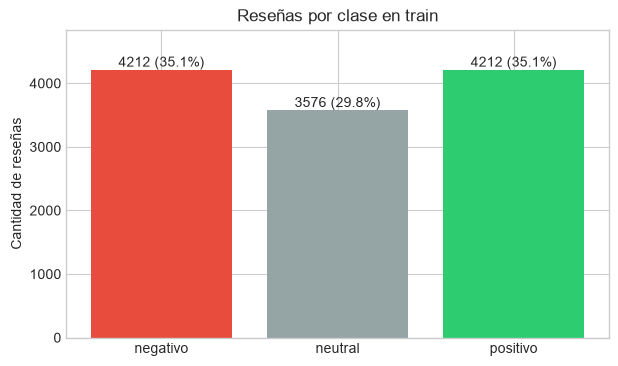

In [4]:
conteo = train['label'].value_counts().reindex(CLASES)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(conteo.index, conteo.values, color=['#E74C3C', '#95A5A6', '#2ECC71'])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 50, f'{v} ({v / len(train):.1%})', ha='center')
ax.set(title='Reseñas por clase en train', ylabel='Cantidad de reseñas', ylim=(0, conteo.max() * 1.15))
plt.show()

Las tres clases están casi balanceadas. La neutral tiene un poco menos de reseñas. Por eso la accuracy es una métrica adecuada y no vemos necesario usar SMOTE como en P9.

### 3.3 Longitud de las reseñas

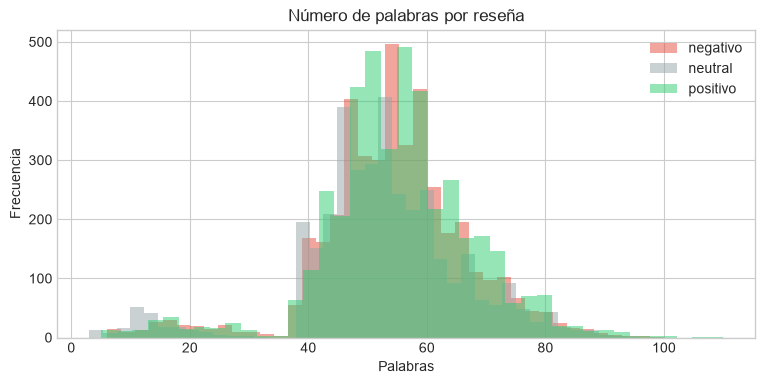

,mean,50%,min,max
label,,,,
negativo,54.2,54.0,6.0,100.0
neutral,52.3,52.0,3.0,96.0
positivo,55.0,55.0,5.0,110.0
eval,54.2,54.0,4.0,104.0


In [5]:
train['n_palabras'] = train['text'].str.split().str.len()
evaluacion['n_palabras'] = evaluacion['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
for clase, color in zip(CLASES, ['#E74C3C', '#95A5A6', '#2ECC71']):
    ax.hist(train.loc[train['label'] == clase, 'n_palabras'], bins=40, alpha=0.5, label=clase, color=color)
ax.set(title='Número de palabras por reseña', xlabel='Palabras', ylabel='Frecuencia')
ax.legend()
plt.show()

resumen_longitud = train.groupby('label')['n_palabras'].describe()[['mean', '50%', 'min', 'max']]
resumen_longitud.loc['eval'] = evaluacion['n_palabras'].describe()[['mean', '50%', 'min', 'max']]
resumen_longitud.round(1)

Las reseñas son cortas, con unas 54 palabras en promedio. La longitud es casi igual en las tres clases y en eval, así que por sí sola no ayuda a distinguirlas.

### 3.4 Ejemplos de cada clase

In [6]:
for clase in CLASES:
    print(f'===== {clase.upper()} =====')
    for texto in train.loc[train['label'] == clase, 'text'].sample(2, random_state=SEMILLA):
        print(f'* {texto}\n')

===== NEGATIVO =====
* La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.

* Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.

===== NEUTRAL =====
* Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves ya lo tenía en casa. Lo entregó la mensajería de siempre, el mismo señor que suele pasar por la cuadra, y me lo dejó en la recepción porque no estaba. La caja venía cerrada con su plástico. Trae garantía de seis meses según el papelito que venía adentro.

* Lo compré hace unas semanas po

Gran parte del texto es relleno: cuándo llegó el pedido, el color, la caja o dónde se usa el producto. Ese relleno aparece en las tres clases. Lo que define el sentimiento son una o dos frases de opinión.

### 3.5 Palabras características de cada clase

Para cada palabra calculamos en qué porcentaje de las reseñas de cada clase aparece. Luego buscamos las que aparecen mucho más en una clase que en las otras.

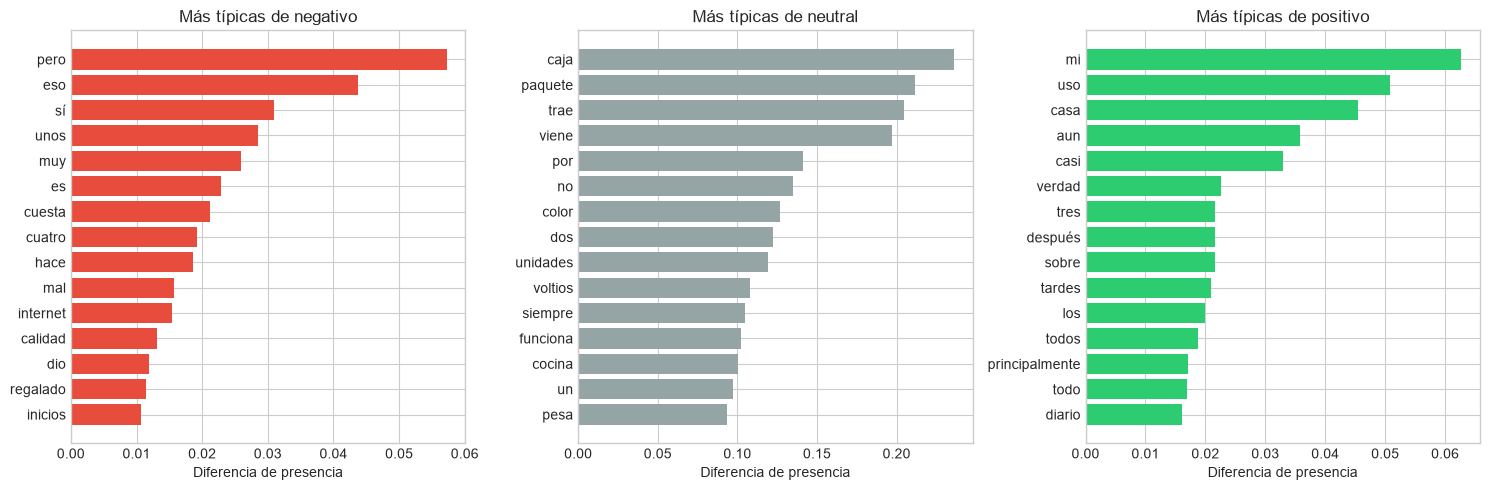

In [7]:
contador = CountVectorizer(binary=True, min_df=20)
matriz = contador.fit_transform(train['text'].str.lower())
vocabulario = contador.get_feature_names_out()

presencia = pd.DataFrame({
    clase: np.asarray(matriz[(train['label'] == clase).values].mean(axis=0)).ravel()
    for clase in CLASES
}, index=vocabulario)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, clase, color in zip(axes, CLASES, ['#E74C3C', '#95A5A6', '#2ECC71']):
    otras = [c for c in CLASES if c != clase]
    diferencia = (presencia[clase] - presencia[otras].max(axis=1)).sort_values().tail(15)
    ax.barh(diferencia.index, diferencia.values, color=color)
    ax.set(title=f'Más típicas de {clase}', xlabel='Diferencia de presencia')
plt.tight_layout()
plt.show()

Las neutrales se reconocen por palabras descriptivas como caja, paquete, trae, viene, color o pesa. En las negativas aparecen "mal", "calidad", "regalado" y el conector "pero". En las positivas la lista es menos clara, con palabras como "uso", "casa" o "diario". Las palabras de opinión positiva cambian mucho de una reseña a otra, así que ninguna sola alcanza a sobresalir. También aparece "aun", que viene de "aun así" y anticipa reseñas con opiniones mezcladas.

### 3.6 Conectores contrastivos y negaciones

El enunciado advierte que muchas reseñas mezclan elogios y quejas. Medimos en qué porcentaje de reseñas de cada clase aparecen algunos conectores y la palabra "no".

In [8]:
expresiones = ['no', 'pero', 'aunque', 'aun así', 'al final', 'eso sí', 'sin embargo']
texto_minus = train['text'].str.lower()

tabla_conectores = pd.DataFrame({
    expresion: texto_minus.str.contains(rf'\b{expresion}\b').groupby(train['label']).mean()
    for expresion in expresiones
}).T.reindex(columns=CLASES)

(tabla_conectores * 100).round(1).rename_axis('Expresión (% de reseñas)')

label,negativo,neutral,positivo
Expresión (% de reseñas),,,
no,27.1,40.6,25.9
pero,9.5,3.7,3.8
aunque,4.9,2.7,3.9
aun así,5.4,0.0,7.3
al final,13.9,0.7,13.7
eso sí,14.3,1.1,12.2
sin embargo,1.5,0.0,1.4


Observamos tres cosas:

1. "no" aparece en una de cada cuatro reseñas positivas o negativas y en el 41% de las neutrales. Si la quitamos como stop word perdemos negaciones como "no funciona".
2. Los conectores casi no aparecen en las neutrales, pero sí en muchas positivas y negativas.
3. "al final", "eso sí" y "aun así" aparecen con la misma frecuencia en positivas y negativas. Indican que hay un cambio de opinión, pero no hacia dónde.

Veamos dos reseñas que muestran el problema:

In [9]:
for id_resena in [5679, 3061]:
    fila = train.loc[train['id'] == id_resena].iloc[0]
    print(f"[{fila['label']}] {fila['text']}\n")

[positivo] Lo compré hace un par de meses para usarlo en la oficina, llegó en tres días. Lo llevo usando un tiempo ya. El acabado se queda muy corto, la verdad. Ahora, la señal es justo lo que estaba buscando, eso sí. Tengo sentimientos encontrados con él.

[negativo] Compré esto a inicios de mes y me llegó como en cuatro días a la casa. Trae garantía de 90 días y el sistema de carga es bien construido para lo que necesitaba. Lo instalé un sábado por la tarde mientras arreglaba el garaje, siguiendo las instrucciones que vienen en la caja. La instalación luce débil comparado con otros.



En la primera reseña hay una queja ("el acabado se queda muy corto") y luego un elogio ("la señal es justo lo que estaba buscando"). La etiqueta es positiva. En la segunda pasa lo contrario: primero un elogio ("bien construido") y al final una queja, y la etiqueta es negativa.

Lo que decide la clase suele ser la última opinión. Una bolsa de palabras no guarda el orden, así que ve las dos reseñas casi igual. Esta será la mayor limitación de los modelos de esta parte.

## 4. Preprocesamiento del texto

Seguimos los pasos de P3: normalización, tokenización, stop words y stemming.

1. **Normalización.** Pasamos a minúsculas y quitamos la puntuación y los números.
2. **Stop words.** Probamos dos listas. La primera es la lista completa de NLTK en español. La segunda es la misma lista sin las negaciones, los intensificadores y los conectores, porque esas palabras sí cambian el sentimiento.
3. **Stemming.** Usamos SnowballStemmer en español para unir formas como "funciona", "funcionó" y "funcionaba".

Definimos una función por cada combinación para poder compararlas dentro de la búsqueda de hiperparámetros.

In [10]:
stemmer = SnowballStemmer('spanish')

STOP_NLTK = set(stopwords.words('spanish'))
PALABRAS_CON_SENTIMIENTO = {
    'no', 'ni', 'sin', 'nada', 'nunca', 'pero', 'aunque', 'contra',
    'muy', 'más', 'poco', 'mucho', 'tanto', 'todo', 'algo', 'sí',
}
STOP_AJUSTADA = STOP_NLTK - PALABRAS_CON_SENTIMIENTO


def normalizar(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)  # quitar puntuación
    texto = re.sub(r'\d+', ' ', texto)       # quitar números
    return re.sub(r'\s+', ' ', texto).strip()


def limpiar_basico(texto):
    return normalizar(texto)


def limpiar_stop_nltk(texto):
    return ' '.join(t for t in normalizar(texto).split() if t not in STOP_NLTK)


def limpiar_stop_ajustada(texto):
    return ' '.join(t for t in normalizar(texto).split() if t not in STOP_AJUSTADA)


def limpiar_stem(texto):
    return ' '.join(stemmer.stem(t) for t in normalizar(texto).split())


def limpiar_stem_stop_ajustada(texto):
    return ' '.join(stemmer.stem(t) for t in normalizar(texto).split() if t not in STOP_AJUSTADA)


LIMPIEZAS = [limpiar_basico, limpiar_stop_nltk, limpiar_stop_ajustada, limpiar_stem, limpiar_stem_stop_ajustada]

print(f'Stop words NLTK: {len(STOP_NLTK)}')
print(f'Stop words ajustada: {len(STOP_AJUSTADA)}')

Stop words NLTK: 313
Stop words ajustada: 299


Así queda una reseña con cada limpieza:

In [11]:
ejemplo = train.loc[train['id'] == 3061, 'text'].iloc[0]
print(f'Original:\n{ejemplo}\n')
for funcion in LIMPIEZAS:
    print(f'{funcion.__name__}:\n{funcion(ejemplo)}\n')

Original:
Compré esto a inicios de mes y me llegó como en cuatro días a la casa. Trae garantía de 90 días y el sistema de carga es bien construido para lo que necesitaba. Lo instalé un sábado por la tarde mientras arreglaba el garaje, siguiendo las instrucciones que vienen en la caja. La instalación luce débil comparado con otros.

limpiar_basico:
compré esto a inicios de mes y me llegó como en cuatro días a la casa trae garantía de días y el sistema de carga es bien construido para lo que necesitaba lo instalé un sábado por la tarde mientras arreglaba el garaje siguiendo las instrucciones que vienen en la caja la instalación luce débil comparado con otros

limpiar_stop_nltk:
compré inicios mes llegó cuatro días casa trae garantía días sistema carga bien construido necesitaba instalé sábado tarde mientras arreglaba garaje siguiendo instrucciones vienen caja instalación luce débil comparado

limpiar_stop_ajustada:
compré inicios mes llegó cuatro días casa trae garantía días sistema carg

Con la lista completa de NLTK desaparecen "no" y "muy", que cambian el sentido de la frase. La lista ajustada las conserva.

Revisamos también cuánto se reduce el vocabulario con cada limpieza:

In [12]:
vocabulario_por_limpieza = pd.DataFrame({
    'Limpieza': [f.__name__ for f in LIMPIEZAS],
    'Palabras únicas': [len(set(' '.join(train['text'].map(f)).split())) for f in LIMPIEZAS],
})
vocabulario_por_limpieza

,Limpieza,Palabras únicas
0,limpiar_basico,5991
1,limpiar_stop_nltk,5833
2,limpiar_stop_ajustada,5847
3,limpiar_stem,3165
4,limpiar_stem_stop_ajustada,3081


El stemming reduce bastante el vocabulario. Las stop words casi no lo cambian, porque son pocas palabras aunque se repitan mucho.

## 5. Partición de los datos

Como en P7 y P8, separamos un 20% de train como prueba interna, de forma estratificada para mantener la proporción de clases. Esa parte no la usamos hasta el final.

Con el 80% restante hacemos validación cruzada estratificada de 5 particiones para elegir la representación, el modelo y sus hiperparámetros. La métrica es accuracy, la misma de la competencia.

Nunca usamos eval.csv para entrenar ni para tomar decisiones. Solo lo usamos para generar el envío.

In [13]:
X = train['text']
y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMILLA
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

print(f'Entrenamiento: {len(X_train)} reseñas')
print(f'Prueba interna: {len(X_test)} reseñas')
pd.DataFrame({'train': y_train.value_counts(normalize=True), 'prueba': y_test.value_counts(normalize=True)}).round(3)

Entrenamiento: 9600 reseñas
Prueba interna: 2400 reseñas


,train,prueba
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


## 6. Elección de la representación

Antes de comparar modelos elegimos cómo convertir el texto en números. Dejamos fijo un modelo sencillo, una regresión logística, y probamos todas las combinaciones de:

1. Las cinco limpiezas de la sección 4.
2. Tres vectorizadores de P3: bolsa de palabras con conteos, bolsa de palabras binaria y TF-IDF con `sublinear_tf`.
3. Tres tamaños de n-gramas: solo palabras, palabras con bigramas y palabras con bigramas y trigramas.

Todo va dentro de un Pipeline que recibe el texto crudo y devuelve la clase.

In [14]:
VECTORIZADORES = {
    'BoW conteo': CountVectorizer(min_df=2),
    'BoW binaria': CountVectorizer(min_df=2, binary=True),
    'TF-IDF': TfidfVectorizer(min_df=2, sublinear_tf=True),
}

pipeline_repr = Pipeline(steps=[
    ('vectorizador', TfidfVectorizer()),
    ('modelo', LogisticRegression(C=10, max_iter=3000)),
])

param_grid_repr = {
    'vectorizador': list(VECTORIZADORES.values()),
    'vectorizador__preprocessor': LIMPIEZAS,
    'vectorizador__ngram_range': [(1, 1), (1, 2), (1, 3)],
}

inicio = time.time()
grid_repr = GridSearchCV(pipeline_repr, param_grid_repr, cv=cv, scoring='accuracy', n_jobs=-1)
grid_repr.fit(X_train, y_train)
print(f'Tiempo: {time.time() - inicio:.0f} s')

Tiempo: 120 s


In [15]:
nombre_vectorizador = {id(v): nombre for nombre, v in VECTORIZADORES.items()}

resultados_repr = pd.DataFrame({
    'Vectorizador': [nombre_vectorizador[id(p['vectorizador'])] for p in grid_repr.cv_results_['params']],
    'Limpieza': [p['vectorizador__preprocessor'].__name__ for p in grid_repr.cv_results_['params']],
    'N-gramas': [str(p['vectorizador__ngram_range']) for p in grid_repr.cv_results_['params']],
    'Accuracy CV': grid_repr.cv_results_['mean_test_score'],
    'Desviación': grid_repr.cv_results_['std_test_score'],
}).sort_values('Accuracy CV', ascending=False)

resultados_repr.head(10).round(4)

,Vectorizador,Limpieza,N-gramas,Accuracy CV,Desviación
38,TF-IDF,limpiar_stem,"(1, 2)",0.7377,0.0114
8,BoW conteo,limpiar_stem,"(1, 2)",0.7354,0.0107
9,BoW conteo,limpiar_stem_stop_ajustada,"(1, 2)",0.7334,0.0075
32,TF-IDF,limpiar_stop_ajustada,"(1, 1)",0.7320,0.0131
24,BoW binaria,limpiar_stem_stop_ajustada,"(1, 2)",0.7319,0.0077
35,TF-IDF,limpiar_basico,"(1, 2)",0.7315,0.0144
13,BoW conteo,limpiar_stem,"(1, 3)",0.7315,0.0134
30,TF-IDF,limpiar_basico,"(1, 1)",0.7315,0.0097
22,BoW binaria,limpiar_stop_ajustada,"(1, 2)",0.7303,0.0071
33,TF-IDF,limpiar_stem,"(1, 1)",0.7303,0.0123


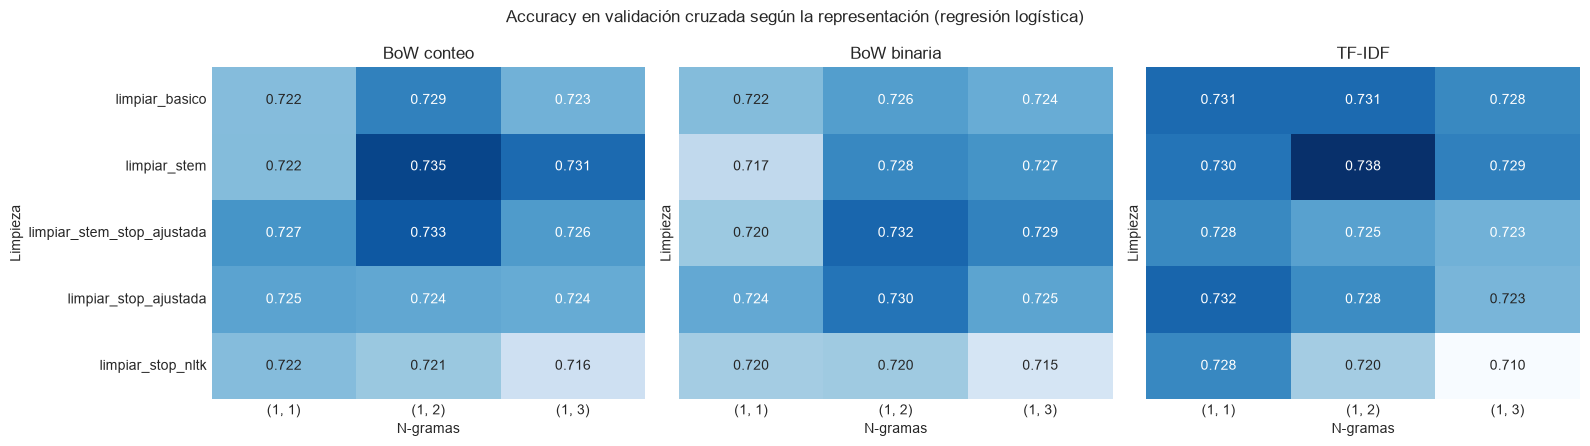

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, vectorizador in zip(axes, VECTORIZADORES):
    tabla = resultados_repr[resultados_repr['Vectorizador'] == vectorizador].pivot(
        index='Limpieza', columns='N-gramas', values='Accuracy CV')
    sns.heatmap(tabla, annot=True, fmt='.3f', cmap='Blues', ax=ax, cbar=False,
                vmin=resultados_repr['Accuracy CV'].min(), vmax=resultados_repr['Accuracy CV'].max())
    ax.set_title(vectorizador)
plt.suptitle('Accuracy en validación cruzada según la representación (regresión logística)')
plt.tight_layout()
plt.show()

Vimos lo siguiente:

1. La lista completa de stop words de NLTK empeora el resultado porque borra "no", "muy" y "pero". La lista ajustada queda casi igual que no quitar nada, así que no aporta.
2. El stemming ayuda un poco porque une variantes de la misma palabra, como "funciona" y "funcionó".
3. Los bigramas suman un poco cuando se combinan con stemming. Capturan expresiones como "me encantó" o "poco fiable". Los trigramas ya no mejoran.
4. Las diferencias entre las mejores representaciones son pequeñas, de menos de un punto. Cambiar la limpieza o el vectorizador no resuelve el problema de fondo, que es el orden.

La mejor combinación fue TF-IDF con stemming, sin quitar stop words y con bigramas. Es la que usamos para comparar modelos.

In [17]:
mejor_repr = grid_repr.best_params_
print('Mejor representación:')
print(f"  Vectorizador: {resultados_repr.iloc[0]['Vectorizador']}")
print(f"  Limpieza: {mejor_repr['vectorizador__preprocessor'].__name__}")
print(f"  N-gramas: {mejor_repr['vectorizador__ngram_range']}")
print(f'  Accuracy CV: {grid_repr.best_score_:.4f}')

Mejor representación:
  Vectorizador: TF-IDF
  Limpieza: limpiar_stem
  N-gramas: (1, 2)
  Accuracy CV: 0.7377


## 7. Comparación de modelos

Con la representación elegida comparamos los clasificadores vistos en el curso:

1. **Naive Bayes multinomial**, mencionado en P3 para texto.
2. **Regresión logística** (P7).
3. **Árbol de decisión** (P8).
4. **KNN** (P9). Usamos la distancia coseno porque es la usual para comparar textos.
5. **Random Forest** (P10).

Cada modelo tiene su propia búsqueda de hiperparámetros con la misma validación cruzada.

In [18]:
def crear_pipeline(modelo):
    vectorizador = clone(mejor_repr['vectorizador']).set_params(
        preprocessor=mejor_repr['vectorizador__preprocessor'],
        ngram_range=mejor_repr['vectorizador__ngram_range'],
    )
    return Pipeline(steps=[
        ('vectorizador', vectorizador),
        ('modelo', modelo),
    ])


busquedas = {
    'Naive Bayes': (MultinomialNB(), {
        'modelo__alpha': [0.01, 0.1, 0.3, 1.0],
    }),
    'Regresión logística': (LogisticRegression(max_iter=3000), {
        'modelo__C': [1, 3, 10, 30],
        'vectorizador__min_df': [1, 2, 3],
    }),
    'Árbol de decisión': (DecisionTreeClassifier(random_state=SEMILLA), {
        'modelo__criterion': ['gini', 'entropy'],
        'modelo__max_depth': [20, 40, None],
        'modelo__min_samples_leaf': [1, 5],
    }),
    'KNN': (KNeighborsClassifier(metric='cosine'), {
        'modelo__n_neighbors': [15, 35, 75],
        'modelo__weights': ['uniform', 'distance'],
    }),
    'Random Forest': (RandomForestClassifier(n_estimators=300, random_state=SEMILLA), {
        'modelo__max_depth': [None, 60],
        'modelo__min_samples_leaf': [1, 2],
    }),
}

grids = {}
resumen_modelos = []
for nombre, (modelo, param_grid) in busquedas.items():
    inicio = time.time()
    grid = GridSearchCV(crear_pipeline(modelo), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    grids[nombre] = grid
    mejor = grid.cv_results_['rank_test_score'].argmin()
    resumen_modelos.append({
        'Modelo': nombre,
        'Accuracy CV': grid.best_score_,
        'Desviación': grid.cv_results_['std_test_score'][mejor],
        'Mejores hiperparámetros': {k.split('__')[1]: v for k, v in grid.best_params_.items()},
        'Tiempo (s)': round(time.time() - inicio),
    })
    print(f'{nombre}: {grid.best_score_:.4f}')

resumen_modelos = pd.DataFrame(resumen_modelos).sort_values('Accuracy CV', ascending=False).reset_index(drop=True)
resumen_modelos.round(4)

Naive Bayes: 0.7115


Regresión logística: 0.7377


Árbol de decisión: 0.5901


KNN: 0.6634


Random Forest: 0.6828


,Modelo,Accuracy CV,Desviación,Mejores hiperparámetros,Tiempo (s)
0,Regresión logística,0.7377,0.0114,"{'C': 10, 'min_df': 2}",52
1,Naive Bayes,0.7115,0.0173,{'alpha': 1.0},18
2,Random Forest,0.6828,0.0082,"{'max_depth': 60, 'min_samples_leaf': 2}",60
3,KNN,0.6634,0.0039,"{'n_neighbors': 75, 'weights': 'uniform'}",28
4,Árbol de decisión,0.5901,0.0063,"{'criterion': 'gini', 'max_depth': 40, 'min_samples_leaf': 1}",67


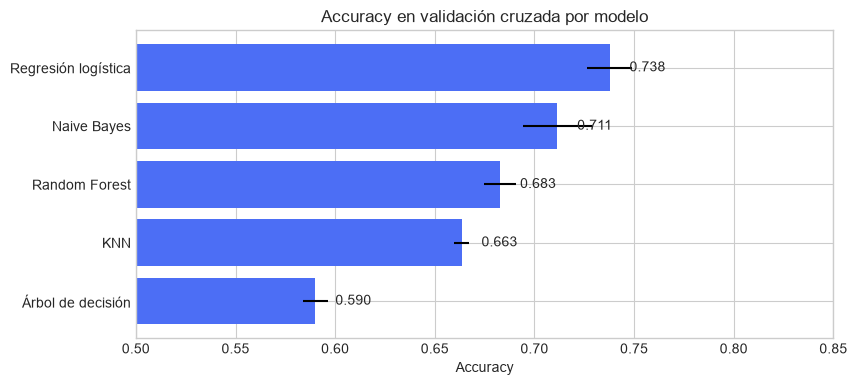

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
orden = resumen_modelos.sort_values('Accuracy CV')
ax.barh(orden['Modelo'], orden['Accuracy CV'], xerr=orden['Desviación'], color='#4C6EF5')
for i, v in enumerate(orden['Accuracy CV']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
ax.set(title='Accuracy en validación cruzada por modelo', xlabel='Accuracy', xlim=(0.5, 0.85))
plt.show()

La regresión logística es la mejor. Con miles de columnas dispersas, un modelo lineal aprovecha bien cada palabra y cada bigrama. Naive Bayes queda cerca, pero supone que las palabras son independientes entre sí.

Los modelos basados en árboles y en vecinos quedan por debajo. Un árbol solo puede mirar unas pocas palabras en cada camino. KNN compara reseñas completas, y como gran parte del texto es relleno, encuentra vecinos que se parecen en el relleno y no en la opinión.

## 8. Evaluación en la prueba interna

Ahora sí usamos el 20% que habíamos guardado, con el mejor modelo de la validación cruzada.

In [20]:
nombre_mejor = resumen_modelos.loc[0, 'Modelo']
mejor_modelo = grids[nombre_mejor].best_estimator_
y_pred = mejor_modelo.predict(X_test)

print(f'Modelo: {nombre_mejor}')
print(f'Accuracy en prueba interna: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, digits=3))

Modelo: Regresión logística
Accuracy en prueba interna: 0.7346

              precision    recall  f1-score   support

    negativo      0.623     0.636     0.629       843
     neutral      0.985     0.999     0.992       715
    positivo      0.630     0.609     0.620       842

    accuracy                          0.735      2400
   macro avg      0.746     0.748     0.747      2400
weighted avg      0.733     0.735     0.734      2400



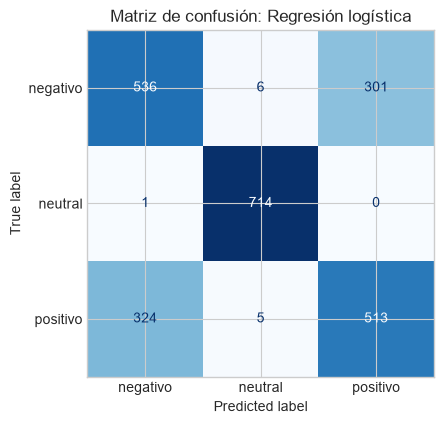

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión: {nombre_mejor}')
plt.show()

La accuracy en la prueba interna es parecida a la de la validación cruzada, así que el modelo no está sobreajustado a las particiones.

La clase neutral es la más fácil, porque no tiene palabras de opinión. La mayoría de los errores son confusiones entre positivo y negativo. Encaja con lo que vimos en la exploración: esas reseñas comparten las mismas palabras de opinión y solo cambia el orden.

## 9. Qué aprendió el modelo

La regresión logística asigna un peso a cada palabra o bigrama por clase. Revisamos los términos con más peso.

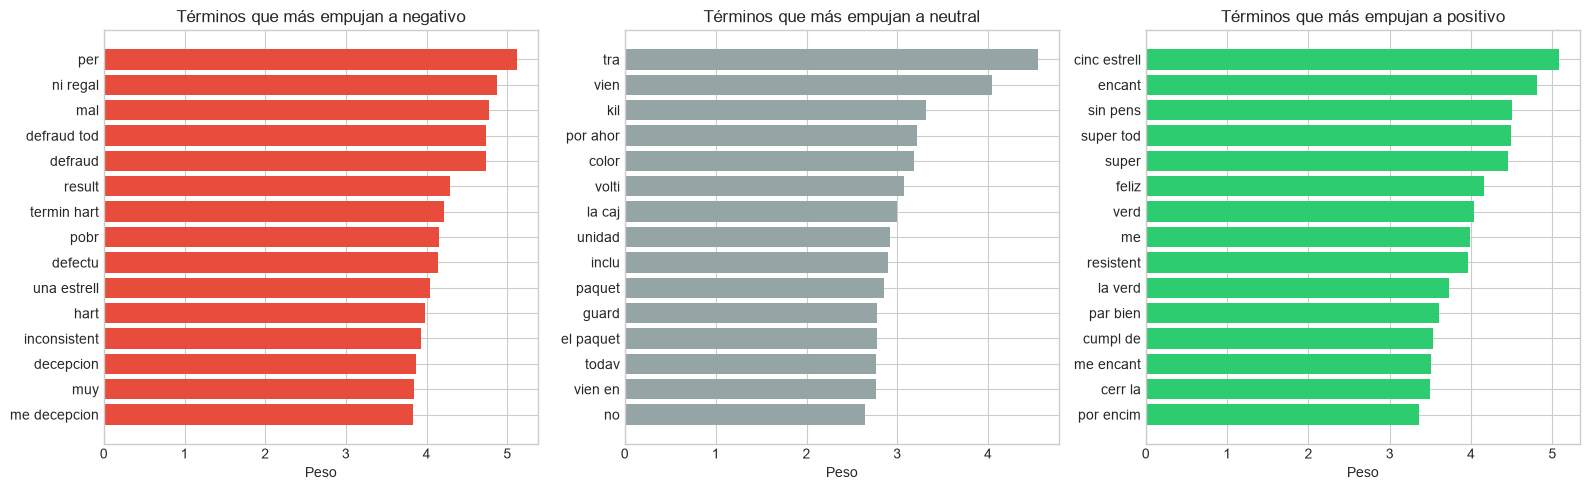

In [22]:
vectorizador_final = mejor_modelo.named_steps['vectorizador']
clasificador = mejor_modelo.named_steps['modelo']
terminos = vectorizador_final.get_feature_names_out()

if hasattr(clasificador, 'coef_'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, i, color in zip(axes, range(3), ['#E74C3C', '#95A5A6', '#2ECC71']):
        pesos = pd.Series(clasificador.coef_[i], index=terminos).sort_values().tail(15)
        ax.barh(pesos.index, pesos.values, color=color)
        ax.set(title=f'Términos que más empujan a {clasificador.classes_[i]}', xlabel='Peso')
    plt.tight_layout()
    plt.show()

Los términos tienen sentido. Hacia negativo empujan "mal", "defectuoso", "decepcionó" o "ni regalado". Hacia positivo empujan "me encantó", "cinco estrellas" o "feliz". Hacia neutral empujan palabras que describen el producto, como "trae", "viene", "color", "la caja" o "paquete". Las palabras aparecen recortadas por el stemming.

El modelo aprende bien qué palabras son buenas o malas. Lo que no puede saber es cuál de las opiniones de la reseña va al final.

## 10. Análisis de errores

Revisamos reseñas de la prueba interna que el modelo clasificó mal.

In [23]:
errores = pd.DataFrame({'texto': X_test, 'real': y_test, 'predicho': y_pred})
errores = errores[errores['real'] != errores['predicho']]

print(f'Errores: {len(errores)} de {len(X_test)}\n')
for _, fila in errores.sample(5, random_state=SEMILLA).iterrows():
    print(f"Real: {fila['real']} | Predicho: {fila['predicho']}")
    print(f"{fila['texto']}\n")

Errores: 637 de 2400

Real: positivo | Predicho: neutral
Lo pedí un martes y me llegó el jueves a casa, sin contratiempos en el envío. Está disponible en cuatro tamaños, yo pedí el mediano para el cuarto de los niños. El ensamblaje funciona de maravilla, con las piezas todas en su lugar y las instrucciones a mano.

Real: negativo | Predicho: positivo
Compre esta senal a mediados de ano y me llego en unos cuatro dias habiles a casa, en la caja tal cual la describian. Queria dejar constancia. La senal resulto bien construida en mi experiencia, la revise apenas la desempaqueto mi hermano en el garaje. Por cierto, el envio lo pague junto con el pedido en linea. Con todo, la tapa me resulto olvidable por lo que pague.

Real: negativo | Predicho: positivo
Lo compré hace unas semanas en línea y llegó en tres días. En pocas palabras, está disponible en varios tamaños, yo pedí el mediano para el escritorio. Además, he de decir que la portabilidad me resultó confiable en estas semanas, lo anduve

En varios errores la reseña tiene una opinión buena y una mala, y el modelo se queda con la que no es la última. Para medirlo separamos la prueba interna en reseñas con algún conector contrastivo y reseñas sin conectores.

In [24]:
patron_contraste = r'\b(?:pero|aunque|aun así|al final|eso sí|sin embargo|lo único)\b'
tiene_contraste = X_test.str.lower().str.contains(patron_contraste)

analisis = pd.DataFrame({
    'Reseñas': [tiene_contraste.sum(), (~tiene_contraste).sum()],
    'Accuracy': [
        accuracy_score(y_test[tiene_contraste], y_pred[tiene_contraste.values]),
        accuracy_score(y_test[~tiene_contraste], y_pred[~tiene_contraste.values]),
    ],
}, index=['Con conector contrastivo', 'Sin conector'])
analisis.round(3)

,Reseñas,Accuracy
Con conector contrastivo,727,0.620
Sin conector,1673,0.784


El modelo acierta el 78% de las reseñas sin conectores, pero solo el 62% de las que tienen alguno. Esto confirma lo que dice el enunciado y lo que vimos en P3: la bolsa de palabras pierde el orden, y en este problema el orden decide muchas veces la clase.

## 11. Fase 2: el orden de las opiniones

En el análisis de errores vimos que la bolsa de palabras falla en las reseñas con opiniones mezcladas. Al leer muchas de ellas encontramos una regla bastante constante: la clase la decide la última opinión, sobre todo cuando va después de un conector como "eso sí", "sin embargo", "al final" o "aunque".

Probamos tres mejoras, una sobre otra. Todas siguen usando TF-IDF, n-gramas y regresión logística. Lo que cambia es qué parte del texto le mostramos al modelo.

### 11.1 Partir la reseña en cláusulas

Una cláusula es un pedazo de la reseña con una sola idea. Cortamos en los puntos y también antes de un conector de contraste que va después de una coma, como en "el soporte es pésimo, aunque la resolución es rapidísima".

In [25]:
CONECTORES_CONTRASTE = (
    r'(?:pero|aunque|eso s[ií]|sin embargo|al final|a fin de cuentas|aun as[ií]|ahora'
    r'|por otro lado|en cambio|lo [uú]nico|no obstante|de todas formas|igual)'
)


def partir_clausulas(texto):
    oraciones = [o.strip() for o in re.split(r'[.!?;]+', texto.lower()) if o.strip()]
    clausulas = []
    for oracion in oraciones:
        # cortar antes de un conector de contraste que sigue a una coma
        partes = re.split(rf',\s*(?={CONECTORES_CONTRASTE}\b)', oracion)
        clausulas.extend(p.strip(' ,') for p in partes if p.strip(' ,'))
    return clausulas or ['']


def ultima_clausula(texto):
    return limpiar_stem(partir_clausulas(texto)[-1])


ejemplo = train.loc[train['text'].str.contains('soporte técnico luce pésimo después de un mes'), 'text'].iloc[0]
print(f'Reseña:\n{ejemplo}\n')
for i, clausula in enumerate(partir_clausulas(ejemplo), 1):
    print(f'{i}. {clausula}')

Reseña:
Lo compré hace un mes en línea y llegó en tres días. Desde entonces lo llevo a todas partes. Trae dos adaptadores incluidos. Eso sí, el soporte técnico luce pésimo después de un mes, aunque al final la resolución me resultó ser rapidísima para lo que cuesta.

1. lo compré hace un mes en línea y llegó en tres días
2. desde entonces lo llevo a todas partes
3. trae dos adaptadores incluidos
4. eso sí, el soporte técnico luce pésimo después de un mes
5. aunque al final la resolución me resultó ser rapidísima para lo que cuesta


La última oración tiene dos opiniones separadas por "aunque". Al partirla, la última cláusula queda solo con la opinión que decide.

### 11.2 Mejora 1: la última cláusula por separado

Al TF-IDF del texto completo le sumamos un segundo TF-IDF hecho solo con la última cláusula. Para eso usamos `FeatureUnion`, que pone las dos matrices una al lado de la otra.

Así una palabra como "pésimo" tiene dos columnas. Una dice si aparece en la reseña y la otra si aparece al final. El modelo puede aprender que la del final pesa más.

In [26]:
def vectorizador_palabras(preprocesador):
    return TfidfVectorizer(preprocessor=preprocesador, ngram_range=(1, 2), min_df=2, sublinear_tf=True)


pipeline_m1 = Pipeline(steps=[
    ('representacion', FeatureUnion([
        ('texto', vectorizador_palabras(limpiar_stem)),
        ('ultima', vectorizador_palabras(ultima_clausula)),
    ])),
    ('modelo', LogisticRegression(max_iter=5000)),
])

inicio = time.time()
grid_m1 = GridSearchCV(pipeline_m1, {'modelo__C': [1, 3, 10]}, cv=cv, scoring='accuracy', n_jobs=-1)
grid_m1.fit(X_train, y_train)

print(f'Mejor C: {grid_m1.best_params_["modelo__C"]}')
print(f'Accuracy CV: {grid_m1.best_score_:.4f}')
print(f'Tiempo: {time.time() - inicio:.0f} s')

Mejor C: 3
Accuracy CV: 0.8924
Tiempo: 19 s


### 11.3 Mejora 2: la última cláusula con opinión

Muchas reseñas cierran con una frase sin opinión, como "Lo dejo a tu criterio" o "En fin, ni fu ni fa". Ahí la última cláusula no dice nada útil.

Para saltarnos esas frases entrenamos primero el modelo de la Fase 1 con las reseñas completas y lo usamos para puntuar cada cláusula. Si el modelo cree que una cláusula es neutral con una probabilidad mayor al umbral, la tomamos como relleno. Nos quedamos con la última cláusula que no es relleno.

Como esto necesita entrenar un modelo por dentro, lo escribimos como un transformador de scikit-learn. Así todo queda dentro del Pipeline y la validación cruzada lo vuelve a entrenar en cada partición sin ver los datos de validación.

In [27]:
class UltimaOpinion(BaseEstimator, TransformerMixin):
    """TF-IDF de la última cláusula con opinión de cada reseña."""

    def __init__(self, umbral=0.5, C=3):
        self.umbral = umbral
        self.C = C

    def fit(self, X, y):
        # modelo de la Fase 1 para reconocer cláusulas sin opinión
        self.puntuador_ = Pipeline(steps=[
            ('vectorizador', vectorizador_palabras(limpiar_stem)),
            ('modelo', LogisticRegression(C=self.C, max_iter=5000)),
        ]).fit(X, y)
        self.vectorizador_ = vectorizador_palabras(limpiar_stem).fit(self.seleccionar(X))
        return self

    def seleccionar(self, X):
        clausulas = [partir_clausulas(t) for t in X]
        todas = [c for lista in clausulas for c in lista]
        indice_neutral = list(self.puntuador_.classes_).index('neutral')
        prob_neutral = self.puntuador_.predict_proba(todas)[:, indice_neutral]

        elegidas, inicio = [], 0
        for lista in clausulas:
            probs = prob_neutral[inicio:inicio + len(lista)]
            inicio += len(lista)
            con_opinion = [c for c, p in zip(lista, probs) if p < self.umbral]
            elegidas.append(con_opinion[-1] if con_opinion else lista[-1])
        return elegidas

    def transform(self, X):
        return self.vectorizador_.transform(self.seleccionar(X))

Veamos qué cláusula elige en dos reseñas que terminan con una frase de relleno. Probamos el umbral de 0.5 y uno más exigente de 0.2:

In [28]:
ejemplos = train.loc[train['text'].str.contains('Lo dejo a tu criterio|En fin, ni fu ni fa'), 'text'].head(2)
elegidas = {umbral: UltimaOpinion(umbral=umbral).fit(X_train, y_train).seleccionar(ejemplos) for umbral in [0.5, 0.2]}

for i, texto in enumerate(ejemplos):
    print(f'Reseña: {texto}')
    print(f'Última cláusula: {partir_clausulas(texto)[-1]}')
    print(f'Última con opinión (umbral 0.5): {elegidas[0.5][i]}')
    print(f'Última con opinión (umbral 0.2): {elegidas[0.2][i]}\n')

Reseña: La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro modelo, pero eso ya es cosa de cada quien. Lo dejo a tu criterio.
Última cláusula: lo dejo a tu criterio
Última con opinión (umbral 0.5): lo dejo a tu criterio
Última con opinión (umbral 0.2): pero eso ya es cosa de cada quien

Reseña: Lo compre hace un mes por internet y me llego en cuatro dias. No pare de tener problemas con la aplicacion desde que lo configure. Lo llevo a todas partes, incluso cuando salgo a caminar en las mananas. El tamano es justo lo que estaba buscando. Lo dejo a tu criterio.
Última cláusula: lo dejo a tu criterio
Última con opinión (umbral 0.5): lo dejo a tu criterio
Última con opinión (umbral 0.2): el tamano es justo lo que estaba buscando

In [29]:
pipeline_m2 = Pipeline(steps=[
    ('representacion', FeatureUnion([
        ('texto', vectorizador_palabras(limpiar_stem)),
        ('opinion', UltimaOpinion()),
    ])),
    ('modelo', LogisticRegression(C=3, max_iter=5000)),
])

inicio = time.time()
scores_m2 = cross_val_score(pipeline_m2, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Accuracy CV: {scores_m2.mean():.4f} ± {scores_m2.std():.4f}')
print(f'Tiempo: {time.time() - inicio:.0f} s')

Accuracy CV: 0.8948 ± 0.0128
Tiempo: 18 s


Con el umbral de 0.5 la frase "Lo dejo a tu criterio" todavía pasa como opinión en las dos reseñas. Con 0.2 la segunda reseña sale bien y el modelo encuentra "el tamaño es justo lo que estaba buscando". En la primera se queda con otra frase de relleno ("pero eso ya es cosa de cada quien"). La selección no es perfecta, pero mejora con un umbral más exigente. Por eso en la sección 11.5 buscamos el mejor umbral.

Para medir la Mejora 2 usamos el umbral de 0.5 y C=3, que fue el mejor valor en la Mejora 1.

### 11.4 Mejora 3: n-gramas de caracteres

Las reseñas tienen errores de tipeo como "sisstema", "microofono" o "auga", y muchas están escritas sin tildes. Para el TF-IDF de palabras, "auga" y "agua" son columnas distintas.

Como muestra P3 en la tokenización por caracteres, también podemos partir el texto en pedazos de letras. Usamos pedazos de 2 a 5 letras dentro de cada palabra (`char_wb`). Así "auga" y "agua" comparten varios pedazos y el modelo ve que se parecen.

In [30]:
pipeline_m3 = Pipeline(steps=[
    ('representacion', FeatureUnion([
        ('texto', vectorizador_palabras(limpiar_stem)),
        ('caracteres', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, sublinear_tf=True)),
        ('opinion', UltimaOpinion()),
    ])),
    ('modelo', LogisticRegression(C=3, max_iter=5000)),
])

inicio = time.time()
scores_m3 = cross_val_score(pipeline_m3, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Accuracy CV: {scores_m3.mean():.4f} ± {scores_m3.std():.4f}')
print(f'Tiempo: {time.time() - inicio:.0f} s')

Accuracy CV: 0.8894 ± 0.0127
Tiempo: 24 s


### 11.5 Ajuste final de hiperparámetros

Con las tres mejoras juntas buscamos el mejor valor de C de la regresión logística y el mejor umbral para decidir si una cláusula es relleno.

A esta altura las diferencias entre versiones son de pocas décimas, menos que la variación entre particiones. Por eso desde aquí usamos validación cruzada repetida: las mismas 5 particiones estratificadas, repetidas 3 veces con distinto orden. Así cada versión se evalúa 15 veces y el promedio es más confiable.

In [31]:
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)

param_grid_final = {
    'modelo__C': [1, 2, 3],
    'representacion__opinion__umbral': [0.2, 0.3, 0.4],
}

inicio = time.time()
grid_final = GridSearchCV(pipeline_m3, param_grid_final, cv=cv_repetida, scoring='accuracy', n_jobs=-1)
grid_final.fit(X_train, y_train)

print(f'Mejores hiperparámetros: {grid_final.best_params_}')
print(f'Accuracy CV repetida: {grid_final.best_score_:.4f}')
print(f'Tiempo: {time.time() - inicio:.0f} s')

pd.DataFrame(grid_final.cv_results_['params']).assign(
    **{'Accuracy CV': grid_final.cv_results_['mean_test_score']}
).pivot(index='modelo__C', columns='representacion__opinion__umbral', values='Accuracy CV').round(4)

Mejores hiperparámetros: {'modelo__C': 3, 'representacion__opinion__umbral': 0.2}
Accuracy CV repetida: 0.8988
Tiempo: 553 s


representacion__opinion__umbral,0.2,0.3,0.4
modelo__C,,,
1,0.8959,0.8936,0.8916
2,0.8981,0.8965,0.8936
3,0.8988,0.8962,0.8934


### 11.6 Comparación de las versiones

Evaluamos cada versión con la misma validación cruzada repetida. Incluimos también la configuración del envío 5 (C=2 y umbral 0.4), que salió de una primera búsqueda con umbrales entre 0.4 y 0.6.

Tiempo: 137 s


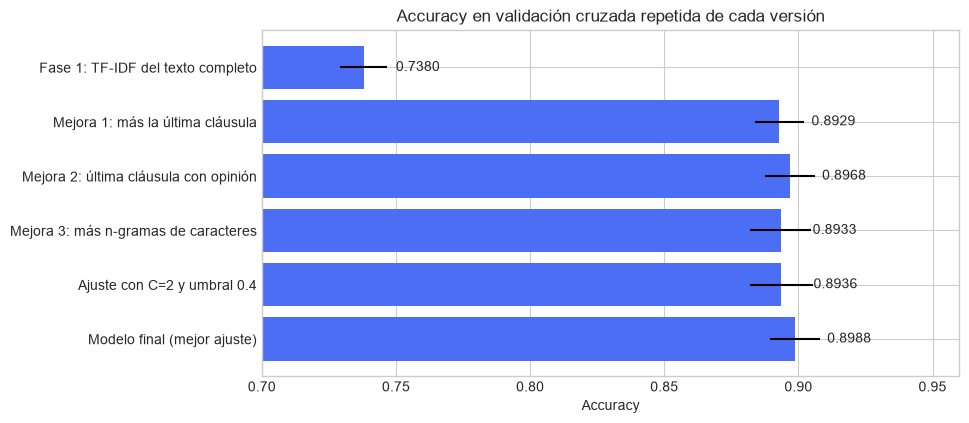

,Versión,Accuracy CV,Desviación
0,Fase 1: TF-IDF del texto completo,0.7380,0.0088
1,Mejora 1: más la última cláusula,0.8929,0.0091
2,Mejora 2: última cláusula con opinión,0.8968,0.0093
3,Mejora 3: más n-gramas de caracteres,0.8933,0.0114
4,Ajuste con C=2 y umbral 0.4,0.8936,0.0116
5,Modelo final (mejor ajuste),0.8988,0.0093


In [32]:
def resultado_grid(grid, params):
    # promedio y desviación de una combinación ya evaluada en la búsqueda
    i = grid.cv_results_['params'].index(params)
    return grid.cv_results_['mean_test_score'][i], grid.cv_results_['std_test_score'][i]


inicio = time.time()
versiones = {
    'Fase 1: TF-IDF del texto completo': grids['Regresión logística'].best_estimator_,
    'Mejora 1: más la última cláusula': grid_m1.best_estimator_,
    'Mejora 2: última cláusula con opinión': pipeline_m2,
    'Mejora 3: más n-gramas de caracteres': pipeline_m3,
}
filas = []
for nombre, pipeline in versiones.items():
    scores = cross_val_score(clone(pipeline), X_train, y_train, cv=cv_repetida, scoring='accuracy', n_jobs=-1)
    filas.append({'Versión': nombre, 'Accuracy CV': scores.mean(), 'Desviación': scores.std()})

media, desv = resultado_grid(grid_final, {'modelo__C': 2, 'representacion__opinion__umbral': 0.4})
filas.append({'Versión': 'Ajuste con C=2 y umbral 0.4', 'Accuracy CV': media, 'Desviación': desv})
filas.append({'Versión': 'Modelo final (mejor ajuste)', 'Accuracy CV': grid_final.best_score_,
              'Desviación': grid_final.cv_results_['std_test_score'][grid_final.best_index_]})
comparacion = pd.DataFrame(filas)
print(f'Tiempo: {time.time() - inicio:.0f} s')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(comparacion['Versión'][::-1], comparacion['Accuracy CV'][::-1],
        xerr=comparacion['Desviación'][::-1], color='#4C6EF5')
for i, v in enumerate(comparacion['Accuracy CV'][::-1]):
    ax.text(v + 0.012, i, f'{v:.4f}', va='center')
ax.set(title='Accuracy en validación cruzada repetida de cada versión', xlabel='Accuracy', xlim=(0.7, 0.96))
plt.show()

comparacion.round(4)

Vimos lo siguiente:

1. La mejora grande viene de la Mejora 1. Solo con mostrarle al modelo la última cláusula por separado pasamos de 0.738 a 0.893.
2. Saltarse las frases de relleno (Mejora 2) suma cerca de medio punto más, hasta 0.897.
3. Los n-gramas de caracteres con el umbral de 0.5 no mejoraron (0.893). La ganancia apareció al bajar el umbral a 0.2, cuando frases como "Lo dejo a tu criterio" dejan de contar como opinión.
4. El modelo final, con C=3 y umbral 0.2, tiene el mejor promedio con 0.899. La configuración del envío 5 queda en 0.894.
5. Las diferencias entre las últimas versiones son menores que la desviación entre particiones, que es cercana a 0.01. Elegimos el modelo final porque tiene el mejor promedio en 15 evaluaciones, pero no esperamos una diferencia grande en Kaggle.

### 11.7 Evaluación en la prueba interna

Usamos otra vez el 20% que guardamos al principio, ahora con el modelo final de la Fase 2.

Accuracy en prueba interna (Fase 1): 0.7346
Accuracy en prueba interna (Fase 2): 0.9000

              precision    recall  f1-score   support

    negativo      0.862     0.856     0.859       843
     neutral      0.996     0.999     0.997       715
    positivo      0.857     0.860     0.858       842

    accuracy                          0.900      2400
   macro avg      0.905     0.905     0.905      2400
weighted avg      0.900     0.900     0.900      2400



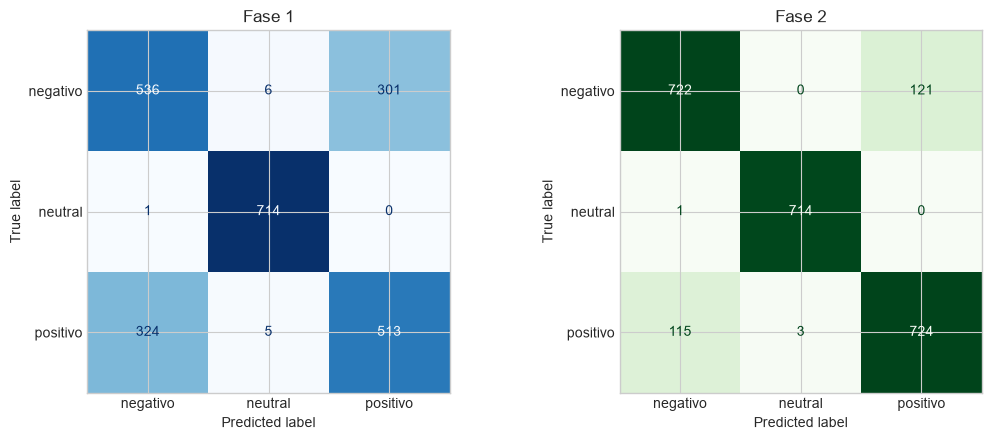

In [33]:
modelo_fase2 = grid_final.best_estimator_
y_pred_fase2 = modelo_fase2.predict(X_test)

print(f'Accuracy en prueba interna (Fase 1): {accuracy_score(y_test, y_pred):.4f}')
print(f'Accuracy en prueba interna (Fase 2): {accuracy_score(y_test, y_pred_fase2):.4f}\n')
print(classification_report(y_test, y_pred_fase2, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=CLASES, cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Fase 1')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_fase2, labels=CLASES, cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title('Fase 2')
plt.tight_layout()
plt.show()

In [34]:
pd.DataFrame({
    'Reseñas': [tiene_contraste.sum(), (~tiene_contraste).sum()],
    'Accuracy Fase 1': [
        accuracy_score(y_test[tiene_contraste], y_pred[tiene_contraste.values]),
        accuracy_score(y_test[~tiene_contraste], y_pred[~tiene_contraste.values]),
    ],
    'Accuracy Fase 2': [
        accuracy_score(y_test[tiene_contraste], y_pred_fase2[tiene_contraste.values]),
        accuracy_score(y_test[~tiene_contraste], y_pred_fase2[~tiene_contraste.values]),
    ],
}, index=['Con conector contrastivo', 'Sin conector']).round(3)

,Reseñas,Accuracy Fase 1,Accuracy Fase 2
Con conector contrastivo,727,0.620,0.911
Sin conector,1673,0.784,0.895


En la prueba interna el modelo final llega a 0.900, frente a 0.735 de la Fase 1. Es casi lo mismo que en la validación cruzada, así que no vemos sobreajuste.

La clase neutral sigue casi perfecta. Los errores en total bajaron de 637 a 240.

El cambio más claro está en las reseñas con conectores contrastivos. Ahí la Fase 1 acertaba el 62% y ahora acierta el 91%. Antes eran las más difíciles y ahora el modelo acierta más en ellas que en las reseñas sin conectores (89.5%).

In [35]:
errores_fase2 = pd.DataFrame({'texto': X_test, 'real': y_test, 'predicho': y_pred_fase2})
errores_fase2 = errores_fase2[errores_fase2['real'] != errores_fase2['predicho']]

print(f'Errores: {len(errores_fase2)} de {len(X_test)}\n')
for _, fila in errores_fase2.sample(5, random_state=SEMILLA).iterrows():
    print(f"Real: {fila['real']} | Predicho: {fila['predicho']}")
    print(f"{fila['texto']}\n")

Errores: 240 de 2400

Real: negativo | Predicho: positivo
Lo compre a inicios de ano en una tienda por departamentos y me llego en tres dias. Despues de usarlo bastante, lo llevo a todas partes, aunque sea al trabajo o al gimnasio. Para ser sincero, la pantalla se sintio redonda para lo que cuesta. Lo pese en una bascula de cocina para un proyecto y ahi confirme que el peso quedo mediocre por lo que pague.

Real: positivo | Predicho: negativo
Lo compré a mediados de año por internet y llegó en unos diez días. El soporte técnico respondió tal como esperaba, sin más. Por otro lado, me arrepiento de haber elegido la nitidez de la imagen. No sabría bien qué recomendar.

Real: positivo | Predicho: negativo
Lo compré hace un par de semanas en una tienda por internet y me llegó al tercer día. Lo uso principalmente para el gimnasio, me lo llevo en la mochila. La autonomía cumple de sobra. Eso sí, el menú de ajustes funciona bastante mal, se traba seguido. Lo dejo a tu criterio.

Real: negativo

En estos cinco ejemplos vemos dos tipos de error:

1. En dos casos la etiqueta sigue la regla de la última opinión, pero el modelo se equivoca. En el primero la opinión final ("el peso quedó mediocre") va al final de una oración larga con relleno. En el cuarto, después de la queja viene una frase de cierre ("ando medio dividido con la compra") que posiblemente el modelo tomó como opinión.
2. En los otros tres la etiqueta va en contra de la regla. Por ejemplo, "La autonomía cumple de sobra. Eso sí, el menú de ajustes funciona bastante mal" está marcada como positiva, aunque la queja va al final.

Al revisar más errores encontramos varios casos con la misma estructura y etiquetas opuestas. Creemos que parte de los errores que quedan no se pueden corregir con ninguna representación, y que el techo de este problema está cerca de 0.91.

## 12. Modelo final y archivo de envío

Reentrenamos el modelo final de la Fase 2 con todo train (100%) y los mejores hiperparámetros. Luego lo guardamos con joblib y generamos `submission.csv`, el envío del mejor modelo.

Para cargar el modelo guardado en otra sesión primero hay que ejecutar las celdas de las secciones 4 y 11, porque el Pipeline usa las funciones de limpieza, `partir_clausulas` y la clase `UltimaOpinion` definidas ahí.

In [36]:
os.makedirs('submissions', exist_ok=True)


def validar_envio(envio):
    assert list(envio.columns) == ['id', 'answer'], 'Columnas incorrectas'
    assert len(envio) == len(evaluacion) == 3000, 'Número de filas incorrecto'
    assert envio['id'].equals(evaluacion['id']), 'Los id no coinciden con eval.csv'
    assert set(envio['answer']).issubset(CLASES), 'Hay etiquetas no válidas'
    assert envio['answer'].notna().all(), 'Hay predicciones vacías'


def generar_envio(modelo, archivo):
    envio = pd.DataFrame({'id': evaluacion['id'], 'answer': modelo.predict(evaluacion['text'])})
    validar_envio(envio)
    envio.to_csv(archivo, index=False)
    return envio

In [37]:
modelo_final = grid_final.best_estimator_
modelo_final.fit(X, y)

ARCHIVO_MODELO = 'modelo_P1_G29.joblib'
joblib.dump(modelo_final, ARCHIVO_MODELO)

ARCHIVO_ENVIO = 'submissions/sub_06_modelo_final.csv'
envio_final = generar_envio(modelo_final, ARCHIVO_ENVIO)

print(f'Modelo guardado en {ARCHIVO_MODELO}')
print(f'Envío guardado en {ARCHIVO_ENVIO}')
print(envio_final['answer'].value_counts(normalize=True).round(3))
envio_final.head()

Modelo guardado en modelo_P1_G29.joblib
Envío guardado en submissions/sub_06_modelo_final.csv
answer
positivo    0.369
negativo    0.355
neutral     0.276
Name: proportion, dtype: float64


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Comprobamos que el modelo guardado se carga y da las mismas predicciones:

In [38]:
modelo_cargado = joblib.load(ARCHIVO_MODELO)
iguales = (modelo_cargado.predict(evaluacion['text']) == envio_final['answer']).all()
print(f'Predicciones idénticas tras cargar el modelo: {iguales}')

Predicciones idénticas tras cargar el modelo: True


## 13. Registro de envíos

Registramos cada versión con su accuracy en validación cruzada repetida y, si la subimos a Kaggle, su score público. Este notebook solo genera el archivo del modelo final.

In [39]:
registro = comparacion[['Versión', 'Accuracy CV']].copy()
registro.insert(0, 'Envío', [
    'sub_01_regresion_logistica.csv',
    'sub_02_ultima_clausula.csv',
    'sub_03_ultima_opinion.csv',
    'sub_04_caracteres.csv',
    'sub_05_ajuste_c2_umbral04.csv',
    'sub_06_modelo_final.csv',
])
registro['Score público'] = [0.73777, 'sin enviar', 'sin enviar', 'sin enviar', 0.90888, 'pendiente']
registro.round(4)

,Envío,Versión,Accuracy CV,Score público
0,sub_01_regresion_logistica.csv,Fase 1: TF-IDF del texto completo,0.7380,0.73777
1,sub_02_ultima_clausula.csv,Mejora 1: más la última cláusula,0.8929,sin enviar
2,sub_03_ultima_opinion.csv,Mejora 2: última cláusula con opinión,0.8968,sin enviar
3,sub_04_caracteres.csv,Mejora 3: más n-gramas de caracteres,0.8933,sin enviar
4,sub_05_ajuste_c2_umbral04.csv,Ajuste con C=2 y umbral 0.4,0.8936,0.90888
5,sub_06_modelo_final.csv,Modelo final (mejor ajuste),0.8988,pendiente


## 14. Conclusiones

1. Los datos llegaron limpios y con clases casi balanceadas, por lo que la accuracy es una métrica adecuada y no hizo falta balancear.
2. En la Fase 1 el mejor modelo fue la regresión logística con TF-IDF, stemming y bigramas, con 0.738 en validación cruzada y 0.73777 en Kaggle. Le siguieron Naive Bayes, Random Forest, KNN y el árbol de decisión.
3. El análisis de errores mostró que la bolsa de palabras falla en las reseñas con opiniones mezcladas. Ahí la clase la decide la última opinión, y esa representación pierde el orden.
4. Sin salirnos de TF-IDF y regresión logística, le mostramos al modelo la última cláusula por separado. Ese solo cambio subió la accuracy de 0.738 a 0.893.
5. Saltarnos las frases de cierre sin opinión, agregar n-gramas de caracteres y ajustar el umbral nos llevó a 0.899 en validación cruzada y 0.900 en la prueba interna. Una configuración anterior de este mismo modelo obtuvo 0.90888 en Kaggle.
6. Las diferencias entre las últimas versiones son pequeñas, y parte de los errores que quedan vienen de etiquetas que contradicen la regla. Por eso elegimos el modelo final con la validación cruzada repetida y no con el leaderboard público, que solo usa el 30% de los datos de prueba.